In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("dinoDatasetCSV.csv")

## Cleaning Large Columns

In [3]:
df["geological_period"].unique()

<StringArray>
[                              'Late Cretaceous',
                                'Early Jurassic',
                               'Middle Jurassic',
                              'Early Cretaceous',
                                 'Late Jurassic',
                                'Late Triassic?',
               'Late Cretaceous (Maastrichtian)',
                                 'Late Triassic',
                   'Late Cretaceous (Campanian)',
                   'Early Jurassic (Sinemurian)',
                     'Early Cretaceous (Aptian)',
                  'Late Jurassic (Kimmeridgian)',
     'Early Jurassic (Sinemurian–Pliensbachian)',
     'Late Cretaceous (Campanian–Maastrichtian)',
                                    'Cretaceous',
                                      'Jurassic',
                  'Late Triassic–Early Jurassic',
                                      'Triassic',
                                'Mid Cretaceous',
                   'Late Cretaceous 

In [4]:
## there's way too many. Let's consolidate
def recode_period(x):
    if not isinstance(x, str):
        return x
        
    x = x.lower()

    if 'cretaceous' in x:
        return 'Cretaceous'
    elif 'jurassic' in x:
        return 'Jurassic'
    elif 'triassic':
        return 'Triassic'
    else:
        'Other'

df['cleaned_geological_period'] = df['geological_period'].apply(recode_period)

In [5]:
df["cleaned_geological_period"].unique()

<StringArray>
['Cretaceous', 'Jurassic', 'Triassic']
Length: 3, dtype: str

In [6]:
df["locomotion"].unique()

<StringArray>
[                        'Bipedal',                     'Quadrupedal',
                        'Bipedal?',                         'Aquatic',
             'Bipedal/Quadrupedal', 'Bipedal (facultative quadruped)',
   'Bipedal/Facultative quadruped',                         'Unknown',
       'Bipedal/Early Quadrupedal',                          'Varies',
             'Quadrupedal/Bipedal',                     'Bipedal (?)',
            'Aquatic (Plesiosaur)',          'Bipedal/Early Sauropod',
                      'Locomotion',                               '?']
Length: 16, dtype: str

In [7]:
## there's too many. Let's consolidate
def recode_locomotion(x):
    if not isinstance(x, str):
        return x
        
    x = x.lower()

    if 'unknown' in x or '?' in x or 'varies' in x:
        return 'Other'

    if 'aquatic' in x:
        return 'Aquatic'
    elif 'bipedal' in x and 'quadrupedal' in x:
        return 'Bipedal/Quadrupedal'    
    elif 'bipedal' in x:
        return 'Bipedal'
    else:
        return 'Quadrupedal'

df['cleaned_locomotion'] = df['locomotion'].apply(recode_locomotion)

In [8]:
df["cleaned_locomotion"].value_counts()

cleaned_locomotion
Bipedal                916
Quadrupedal            596
Other                   14
Bipedal/Quadrupedal     13
Aquatic                  3
Name: count, dtype: int64

In [9]:
df["diet"].unique()

<StringArray>
[           'Carnivore',            'Herbivore',             'Omnivore',
 'Carnivore (disputed)',        'Ceric unknown',          'Insectivore',
              'Unknown',   'Possibly carnivore',       'Tiny herbivore',
                 'Diet',                    '?']
Length: 11, dtype: str

In [10]:
## there's too many. Let's consolidate
def recode_diet(x):
    if not isinstance(x, str):
        return x
        
    x = x.lower()

    if 'unknown' in x or '?' in x:
        return 'Other'

    if 'carnivore' in x:
        return 'Carnivore'
    elif 'herbivore' in x:
        return 'Herbivore'    
    elif 'omnivore' in x:
        return 'Omnivore'
    else:
        return 'Insectivore'

df['cleaned_diet'] = df['diet'].apply(recode_diet)

In [11]:
df["cleaned_diet"].value_counts()

cleaned_diet
Herbivore      972
Carnivore      505
Omnivore        53
Other           10
Insectivore      2
Name: count, dtype: int64

In [12]:
df["intelligence_level"].unique()

<StringArray>
[         'Medium',             'Low',      'Very Large',           'Large',
            'Tiny',         'Unknown',            'High', 'Possibly medium',
           'Small',            'Size',               '?',            'Huge',
      'Very small',      'Very large']
Length: 14, dtype: str

In [13]:
## there's too many. Let's consolidate
def recode_intelligence_level(x):
    if not isinstance(x, str):
        return x
        
    x = x.lower()

    if 'unknown' in x or '?' in x:
        return 'Other'

    if 'small' in x or 'low' in x or 'tiny' in x:
        return 'Small'
    elif 'medium' in x:
        return 'Medium'    
    else:
        return 'Large'

df['cleaned_intelligence_level'] = df['intelligence_level'].apply(recode_intelligence_level)

In [14]:
df["cleaned_intelligence_level"].value_counts()

cleaned_intelligence_level
Medium    778
Small     385
Other     194
Large     185
Name: count, dtype: int64

In [15]:
df["first_discovered"].unique()

<StringArray>
['1985', '1974', '1959', '2010', '2011', '1865', '1993', '2007', '1877',
 '1991',
 ...
 '1940', '1907', '1928', '1944', '1808', '1909', '1978', 'Year',    '?',
 '2023']
Length: 171, dtype: str

In [16]:
def recode_first_discovered(x):
    if not isinstance(x, str):
        return x
        
    x = x.lower()

    if 'unknown' in x or '?' in x:
        return 'Other'

    if '18' in x :
        return '1800-1899'
    elif '19' in x:
        return '1900-1999'    
    else:
        return '>2000'

df['cleaned_first_discovered'] = df['first_discovered'].apply(recode_first_discovered)

In [17]:
df["cleaned_first_discovered"].value_counts()

cleaned_first_discovered
>2000        705
1900-1999    646
1800-1899    186
Other          5
Name: count, dtype: int64

In [18]:
fossil_location_vc = df["fossil_location"].value_counts()

rare_locations = fossil_location_vc[fossil_location_vc < 5].index

In [19]:
def recode_fossil_location(x):
    if not isinstance(x, str):
        return 'Other'
    
    if x in rare_locations:
        return 'Other'
    else:
        return x

df['cleaned_fossil_location'] = df['fossil_location'].apply(recode_fossil_location)

## Data Analysis

In [20]:
df.describe(include = 'str')

,scientific_name,common_name,meaning,diet,locomotion,geological_period,lived_in,behavior_notes,first_discovered,fossil_location,notable_features,intelligence_level,source_link,cleaned_geological_period,cleaned_locomotion,cleaned_diet,cleaned_intelligence_level,cleaned_first_discovered,cleaned_fossil_location
count,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542
unique,1538,1527,1338,11,16,73,133,599,171,351,744,14,1524,3,5,5,4,4,34
top,Kritosaurus,Kritosaurus,Different lizard,Herbivore,Bipedal,Late Cretaceous,North America,Theropod dinosaur,2019,China,Large sauropod,Medium,https://en.wikipedia.org/wiki/Kritosaurus,Cretaceous,Bipedal,Herbivore,Medium,>2000,Other
freq,3,3,20,971,913,659,253,265,100,238,86,777,3,1010,916,972,778,705,437


### outliers

In [21]:
## clipping outliers
def IQR(col):
    q1,q3 = np.percentile(col,[25,75])
    iqr = q3 - q1
    lw = q1 - 1.5 * iqr
    uw = q3 + 1.5 * iqr
    return lw,uw

for x in ['length_m', 'weight_kg', 'height_m']:
    lw,uw = IQR(df[x])
    df[x] = np.clip(df[x], lw, uw)

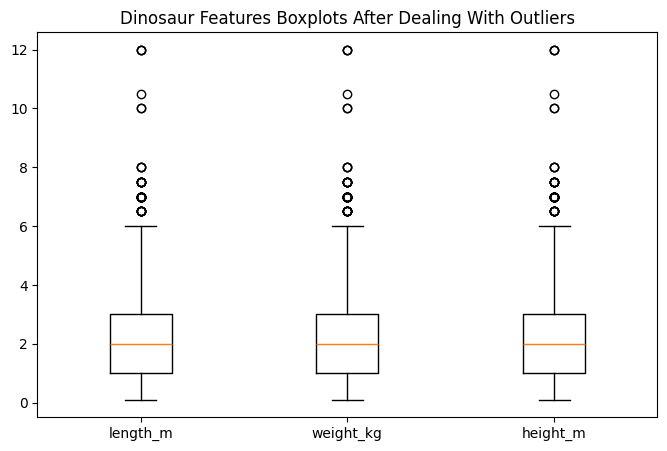

In [22]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [df[x].dropna() for col in ['length_m','weight_kg','height_m']],
    tick_labels=['length_m','weight_kg','height_m']
)

plt.title("Dinosaur Features Boxplots After Dealing With Outliers")
plt.show()

## Check + Replace nan

In [23]:
df.isnull()

,scientific_name,common_name,meaning,diet,length_m,weight_kg,height_m,locomotion,geological_period,lived_in,...,notable_features,intelligence_level,source_link,row_index,cleaned_geological_period,cleaned_locomotion,cleaned_diet,cleaned_intelligence_level,cleaned_first_discovered,cleaned_fossil_location
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1537,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1538,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1539,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1540,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [24]:
np.any(df.isnull())

np.True_

In [25]:
## https://www.geeksforgeeks.org/python/check-for-nan-in-pandas-dataframe/

# applying the method
count_nan = df.isnull().sum()

# printing the number of values present
# in the column
print('Number of NaN values present: ' + str(count_nan))

Number of NaN values present: scientific_name                0
common_name                    0
meaning                        0
diet                           0
length_m                      39
weight_kg                     38
height_m                      32
locomotion                     0
geological_period              0
lived_in                       0
behavior_notes                 0
first_discovered               0
fossil_location                0
notable_features               0
intelligence_level             0
source_link                    0
row_index                      0
cleaned_geological_period      0
cleaned_locomotion             0
cleaned_diet                   0
cleaned_intelligence_level     0
cleaned_first_discovered       0
cleaned_fossil_location        0
dtype: int64


In [26]:
## Most of the dinosaurs that were missing height also missed weight and length. Dinosaurs with three unknowns were dropped

df_dropped_based_on_height = df.dropna(subset=['height_m'])

In [27]:
# applying the method
count_nan_2 = df_dropped_based_on_height.isnull().sum()

# printing the number of values present
# in the column
print('Number of NaN values present: ' + str(count_nan_2))

Number of NaN values present: scientific_name               0
common_name                   0
meaning                       0
diet                          0
length_m                      7
weight_kg                     6
height_m                      0
locomotion                    0
geological_period             0
lived_in                      0
behavior_notes                0
first_discovered              0
fossil_location               0
notable_features              0
intelligence_level            0
source_link                   0
row_index                     0
cleaned_geological_period     0
cleaned_locomotion            0
cleaned_diet                  0
cleaned_intelligence_level    0
cleaned_first_discovered      0
cleaned_fossil_location       0
dtype: int64


In [28]:
# Replace "?" with blank entries
df_dropped_height_replaced_qs = df_dropped_based_on_height.replace("?", "")

# Preview result
print(df_dropped_height_replaced_qs.head())

  scientific_name    common_name          meaning       diet  length_m  \
0     Abelisaurus    Abelisaurus    Abel's lizard  Carnivore       7.0   
1   Abrictosaurus  Abrictosaurus   Wakeful lizard  Herbivore       1.5   
2      Abrosaurus     Abrosaurus  Delicate lizard  Herbivore       9.0   
3     Abydosaurus    Abydosaurus    Abydos lizard  Herbivore      18.0   
4    Acantholipan   Acantholipan     Spiny shield  Herbivore       5.0   

   weight_kg  height_m   locomotion geological_period      lived_in  ...  \
0     1500.0       2.4      Bipedal   Late Cretaceous     Argentina  ...   
1       15.0       0.5      Bipedal    Early Jurassic  South Africa  ...   
2     2000.0       4.5  Quadrupedal   Middle Jurassic         China  ...   
3    30000.0       6.0  Quadrupedal  Early Cretaceous           USA  ...   
4     2500.0       1.5  Quadrupedal   Late Cretaceous        Mexico  ...   

        notable_features intelligence_level  \
0             Short arms             Medium   
1   

In [29]:
# applying the method
count_nan_3 = df_dropped_height_replaced_qs.isnull().sum()

# printing the number of values present
# in the column
print('Number of NaN values present: ' + str(count_nan_3))

Number of NaN values present: scientific_name               0
common_name                   0
meaning                       0
diet                          0
length_m                      7
weight_kg                     6
height_m                      0
locomotion                    0
geological_period             0
lived_in                      0
behavior_notes                0
first_discovered              0
fossil_location               0
notable_features              0
intelligence_level            0
source_link                   0
row_index                     0
cleaned_geological_period     0
cleaned_locomotion            0
cleaned_diet                  0
cleaned_intelligence_level    0
cleaned_first_discovered      0
cleaned_fossil_location       0
dtype: int64


In [30]:
df_new = df_dropped_height_replaced_qs.dropna(subset=['length_m'])

In [31]:
df_new.loc[df_new["weight_kg"].isna(), "weight_kg"] = 300.0

In [32]:
df_new = df_new.drop(columns=["notable_features", "scientific_name", "common_name", "meaning", "behavior_notes", "row_index", "source_link",
                             "intelligence_level", "lived_in", "geological_period", "locomotion", "diet", "first_discovered",
                             "fossil_location"])

In [33]:
df_new = pd.get_dummies(df_new, columns=["cleaned_locomotion", "cleaned_diet", "cleaned_intelligence_level",
                                        "cleaned_first_discovered", "cleaned_fossil_location"])

In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_new["cleaned_geological_period"] = le.fit_transform(df_new["cleaned_geological_period"])

In [35]:
df_new

,length_m,weight_kg,height_m,cleaned_geological_period,cleaned_locomotion_Aquatic,cleaned_locomotion_Bipedal,cleaned_locomotion_Bipedal/Quadrupedal,cleaned_locomotion_Other,cleaned_locomotion_Quadrupedal,cleaned_diet_Carnivore,...,cleaned_fossil_location_Other,cleaned_fossil_location_Portugal,cleaned_fossil_location_Russia,"cleaned_fossil_location_Sichuan, China",cleaned_fossil_location_South Africa,cleaned_fossil_location_Spain,cleaned_fossil_location_Tanzania,cleaned_fossil_location_Thailand,cleaned_fossil_location_UK,cleaned_fossil_location_USA
0,7.0,1500.0,2.4,0,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,1.5,15.0,0.5,1,False,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,9.0,2000.0,4.5,1,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,18.0,30000.0,6.0,0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
4,5.0,2500.0,1.5,0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1537,7.0,700.0,2.5,0,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1538,4.5,1500.0,2.0,0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1539,5.0,2000.0,1.5,0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1540,25.0,30000.0,6.0,0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


## Train/Test

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X = df_new.drop('cleaned_geological_period', axis = 1)
y = df_new['cleaned_geological_period']

print('Target variable distribution:')
print(y.value_counts().sort_index())
print(f'\nClass mapping: 0 = Cretaceous, 1 = Jurassic, 2 = Triassic\n')

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 42, stratify = y)

print(f'Training set size: {X_train.shape[0]} samples')
print(f'Test set size: {X_test.shape[0]} samples')
print(f'Number of features: {X_train.shape[1]}')

Target variable distribution:
cleaned_geological_period
0    988
1    439
2     76
Name: count, dtype: int64

Class mapping: 0 = Cretaceous, 1 = Jurassic, 2 = Triassic

Training set size: 1202 samples
Test set size: 301 samples
Number of features: 55


## Scaling

In [38]:
from sklearn.preprocessing import StandardScaler

## using this for logistic regression and KNN

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## KNN

In [39]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


In [40]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    KNeighborsClassifier(n_neighbors = 5)
)

model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)

model_knn = KNeighborsClassifier(n_neighbors = 5)
model_knn.fit(X_train_scaled, y_train)

y_pred_knn = model_knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.7043189368770764
              precision    recall  f1-score   support

           0       0.73      0.88      0.80       198
           1       0.58      0.40      0.47        88
           2       1.00      0.13      0.24        15

    accuracy                           0.70       301
   macro avg       0.77      0.47      0.50       301
weighted avg       0.70      0.70      0.68       301



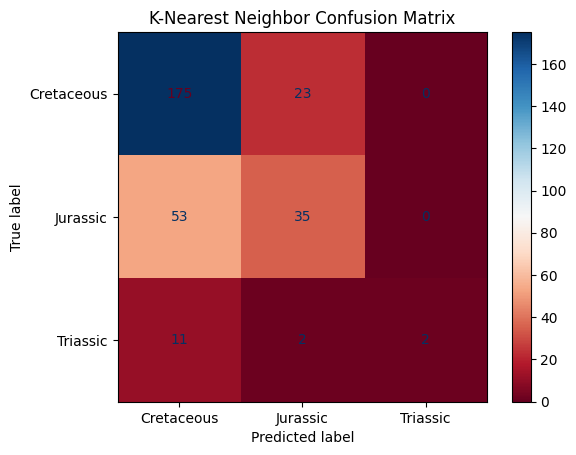

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay
cm_display_knn = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_knn), 
                                            display_labels=["Cretaceous", "Jurassic", "Triassic"])

cm_display_knn.plot(cmap='RdBu')
plt.title('K-Nearest Neighbor Confusion Matrix')
plt.show()

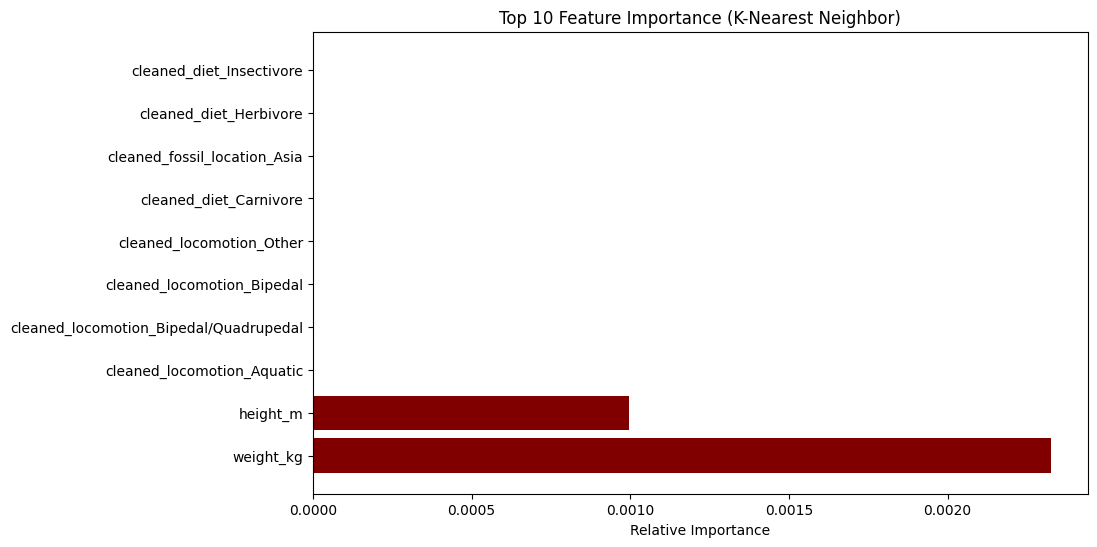

In [42]:
from sklearn.inspection import permutation_importance
result_knn = permutation_importance(
    model_knn, X_test.values, y_test,
    n_repeats=10,
    random_state=42
)

importance_knn = result_knn.importances_mean
feature_importance_knn = pd.Series(importance_knn, index=X.columns)
feature_importance_knn = feature_importance_knn.sort_values(ascending=False)


plt.figure(figsize=(10,6))
plt.barh(feature_importance_knn.index[:10], feature_importance_knn.values[:10],color = 'maroon')
plt.title("Top 10 Feature Importance (K-Nearest Neighbor)")
plt.xlabel("Relative Importance")
plt.show()